In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

ret = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)["^GSPC"]

# Gaussian innovations
g_norm = arch_model(ret, mean="Constant", vol="GARCH", p=1, q=1, dist="normal").fit(disp="off")
print(g_norm.summary())

# Student-t innovations
g_t = arch_model(ret, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(g_t.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3231.95
Distribution:                  Normal   AIC:                           6471.90
Method:            Maximum Likelihood   BIC:                           6495.22
                                        No. Observations:                 2515
Date:                Fri, May 15 2026   Df Residuals:                     2514
Time:                        17:11:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0793  1.485e-02      5.342  9.197e-08 [5.021e-0

Extract conditional volatility:

In [3]:
sigma_garch = g_t.conditional_volatility   # daily conditional std dev
sigma_garch.name = "sigma_garch"

Compute one-step-ahead 99% VaR (in-sample, for now):

In [4]:
from scipy.stats import t as student_t

nu = g_t.params["nu"]                       # degrees of freedom
mu_hat = g_t.params["mu"]                   # constant mean
q99 = student_t.ppf(0.01, df=nu)            # 1st percentile of standardised t

var99_garch = mu_hat + sigma_garch * q99    # negative number; loss threshold
var99_garch.name = "var99_garch"

Plot the conditional volatility:

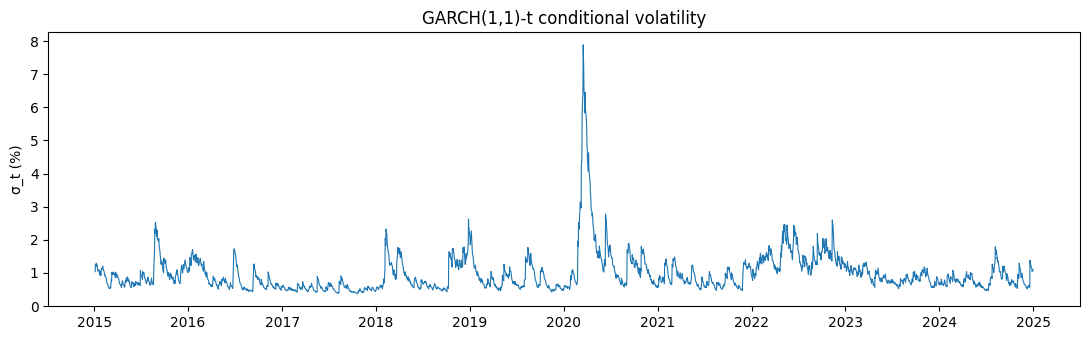

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sigma_garch.index, sigma_garch, lw=0.8)
ax.set_title("GARCH(1,1)-t conditional volatility")
ax.set_ylabel("σ_t (%)")
plt.tight_layout()
plt.savefig("../figures/garch_vol.png", dpi=150)
plt.show()

Save for later comparison:

In [9]:
out = pd.concat([ret, sigma_garch, var99_garch], axis=1)
out.to_csv("../data/garch_output.csv")